# Pipeline evaluation

in questo notebook analizziamo le performance della nostra pipeline, partiamo dallo speigare il dataset, poi eseguiamo la pipeline sui dati che abbiamo raccolto e poi faremo delle analisi delle metriche.

In [54]:
import os
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from sklearn.metrics import auc
from tqdm.notebook import tqdm



In [55]:
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

In [56]:
from detecVisage import FacesDetects_from_bytes
from faceAlignment import align_crop
from embeddings import get_embedding
from qdrant_client import QdrantClient

In [57]:
EVAL_DIR = "images/evaluation_set"
UNKNOWN_LABEL = "unknown"
MODEL_PATH = "model/blaze_face_short_range.tflite"
THRESHOLD = np.arange(0.0, 1.01, 0.01) 
client = QdrantClient(host="10.233.220.118", port=6333)

#mediapipe initialization
base_options = python.BaseOptions(model_asset_path=MODEL_PATH)
options = vision.FaceDetectorOptions(base_options=base_options)
detector = vision.FaceDetector.create_from_options(options)

## Dataset Description

The evaluation dataset is located in the `images/evaluation_set` folder and consists of two main parts:
- **Registered persons (genuine)**: photographs of people already stored in the database, never seen during training.
- **Impostors**: photographs of people who are not present in the database.

Each registered person has a dedicated folder named exactly as their identity in the database. 
Each folder contains photographs of the person under different acquisition conditions: normal, glasses, hat, mask, and low light.

### File Naming Convention
To enable condition-based analysis, each photograph follows the naming convention:
`<name>_<condition><index>.jpg`
where `<index>` allows multiple photographs per condition (e.g., `lea_glasses1.jpg`, `lea_glasses2.jpg`).

### Data Collection
The dataset was entirely collected by the authors (Lea Carminati and Anthony Miranda). 
Photographs of registered persons were taken directly by the authors. 
Impostor photographs were sourced from Pexels (https://www.pexels.com), 
a royalty-free image platform, ensuring legal and ethical use of the data.

In [58]:

people = [p for p in os.listdir(EVAL_DIR) if os.path.isdir(os.path.join(EVAL_DIR, p))]

for person in sorted(people):
    photos = [f for f in os.listdir(os.path.join(EVAL_DIR, person)) 
              if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    print(f"{person} : {len(photos)} photos")

total_photos = sum(
    len([f for f in os.listdir(os.path.join(EVAL_DIR, p)) 
         if f.lower().endswith((".jpg", ".jpeg", ".png"))])
    for p in people
)

genuine_people = [p for p in people if p != UNKNOWN_LABEL]
print(f"\nPersonne enregistrées : {len(genuine_people)}")
print(f"Total photos : {total_photos}")

anthony miranda : 12 photos
clémentine beaulieu : 13 photos
florient marchal : 10 photos
kardiatou ba : 9 photos
lea carminati : 9 photos
sidney dachez : 11 photos
unknown : 15 photos

Personne enregistrées : 6
Total photos : 79


count type of conditions ( glasses, hat, light)

In [59]:
condition_results = defaultdict(int)
for p in people:
    if p == UNKNOWN_LABEL:
        continue
    
    photos = [f for f in os.listdir(os.path.join(EVAL_DIR, p)) 
              if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    for r in photos:
        filename = r
        try:
            condition = r.split("_")[1].split(".")[0].rstrip("0123456789")
        except:
            condition = "unknown"
        condition_results[condition] += 1

visualisations

Text(0.5, 1.0, 'Distribution of photos by evaluation condition')

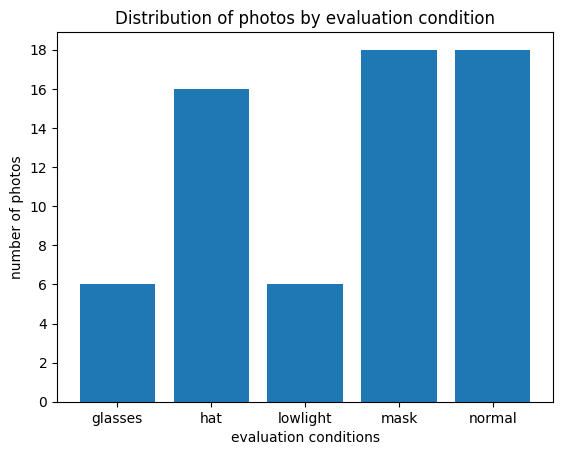

In [60]:
ax = plt.bar(condition_results.keys(), condition_results.values())
plt.xlabel("evaluation conditions")
plt.gca().yaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.ylabel("number of photos")
plt.title("Distribution of photos by evaluation condition")


## Pipeline Execution

We now run the full recognition pipeline on every image in the evaluation dataset.
For each photograph, the following four steps are applied sequentially:

1. **Face Detection** (MediaPipe BlazeFace): detects the face in the image and returns a bounding box.
2. **Alignment & Crop** (`align_crop`): crops and normalizes the detected face — eyes are aligned and the image is resized to a fixed dimension.
3. **Embedding extraction** (ArcFace): encodes the cropped face into a fixed-size feature vector in a metric space.
4. **Vector search** (Qdrant, cosine similarity): queries the database to find the closest stored identity and returns a similarity score and the predicted name. If no match is found, the identity is labelled `unknown`.

Each processed image is stored as a dictionary in the `results` list with the following fields:

| Field | Description |
|---|---|
| `label_true` | Ground truth identity (folder name) |
| `predicted_name` | Identity predicted by the system |
| `score` | Cosine similarity score returned by Qdrant |
| `is_genuine` | `True` if the person is registered in the database, `False` if impostor |
| `photo` | Filename of the image |

Images where no face is detected are skipped and reported.

In [61]:

results=[]
detection_failures = []

for person_name in tqdm(os.listdir(EVAL_DIR)):
    person_dir = os.path.join(EVAL_DIR, person_name)
    if not os.path.isdir(person_dir):
        continue

    for img_name in os.listdir(person_dir):
        if not img_name.lower().endswith((".jpg", ".jpeg", ".png")):
            continue

        img_path = os.path.join(person_dir, img_name)
        with open(img_path, "rb") as f:
            image_bytes = f.read()

        boxes_face, detection_result, image = FacesDetects_from_bytes(image_bytes,"mediapipe",detector)
        if not detection_result or not detection_result.detections:
            print(f"Aucun visage détecté : {img_name}")
            detection_failures.append(img_name)
            continue

        crops = align_crop(image, detection_result)

        #compute embedding with Arcface
        embedding = get_embedding(crops[0])

        #search in Qdrant to get raw score and predicted name
        raw = client.query_points(
                    collection_name="face",
                    query=embedding.tolist(),
                    limit=1
                ).points

        if not raw:
            score = 0.0
            predicted_name = "unknown"
        else:
            score = raw[0].score
            predicted_name = raw[0].payload["name"]

        results.append({
            "label_true": person_name, #folder name, true label
            "predicted_name": predicted_name, # system prediction
            "score": score, #cosine similarity score
            "is_genuine": person_name != UNKNOWN_LABEL, # True if it's a registered person, False if it's an impostor (unknown)
            "photo": img_name
        })


#separate genuine and impostor results for metric calculations
genuine_results  = [r for r in results if r["is_genuine"]]
impostor_results = [r for r in results if not r["is_genuine"]]

print(f"Total photos processed : {len(results)}")
print(f"  Genuine   : {len(genuine_results)}")
print(f"  Impostors : {len(impostor_results)}")


  0%|          | 0/7 [00:00<?, ?it/s]

Aucun visage détecté : anthony_hat1.jpg
Aucun visage détecté : anthony_hat3.jpg
Aucun visage détecté : anthony_mask1.jpg
Aucun visage détecté : clem_hat2.jpg
Aucun visage détecté : flo_mask2.jpg
Aucun visage détecté : flo_mask3.jpg
Aucun visage détecté : ka_hat2.jpg
Aucun visage détecté : ka_mask1.jpg
Aucun visage détecté : ka_mask2.jpg
Aucun visage détecté : lea_hat4.jpg
Aucun visage détecté : lea_mask2.jpg
Aucun visage détecté : sid_mask1.jpg
Total photos processed : 67
  Genuine   : 52
  Impostors : 15


## Detection failure analysis

Text(0.5, 1.0, 'Distribution of photos by evaluation condition')

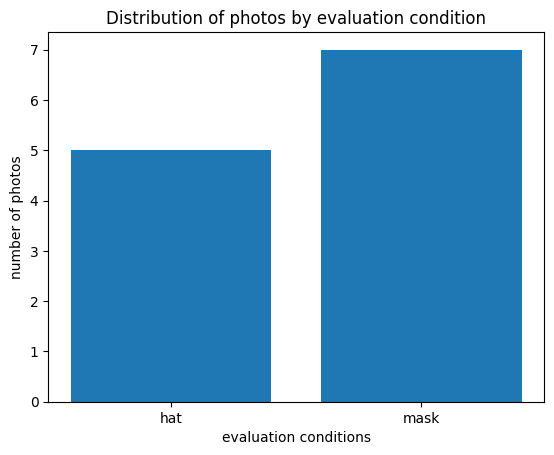

In [62]:
failures_by_condition = defaultdict(int)
for filename in detection_failures:
    try:
        condition = filename.split("_")[1].split(".")[0].rstrip("0123456789")
    except:
        condition = "unknown"
    failures_by_condition[condition] += 1

ax = plt.bar(failures_by_condition.keys(), failures_by_condition.values())
plt.xlabel("evaluation conditions")
plt.gca().yaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.ylabel("number of photos")
plt.title("Distribution of photos by evaluation condition")


The bar chart above shows the number of detection failures per acquisition condition.The two main sources of failure are **mask** (7 failures) and **hat** (5 failures).

This result is expected: MediaPipe BlazeFace relies on facial landmarks 
(eyes, nose, mouth) to detect a face. When these key points are occluded 
by a mask or a hat, the detector fails to identify the presence of a face in the image.

A manual inspection of the failed images reveals that failures occur predominantly 
in photographs where **both eyes are not clearly visible**. In contrast, images where at least one eye is visible are correctly detected. This suggests that eye visibility is a critical factor for the BlazeFace detector.

It is important to note that these failures occur at the **detection stage**, before any embedding or identification is performed. These images are therefore excluded from the subsequent metric calculations (TAR, FAR, FRR, EER).

## Genuine and impostor score distribution analysis

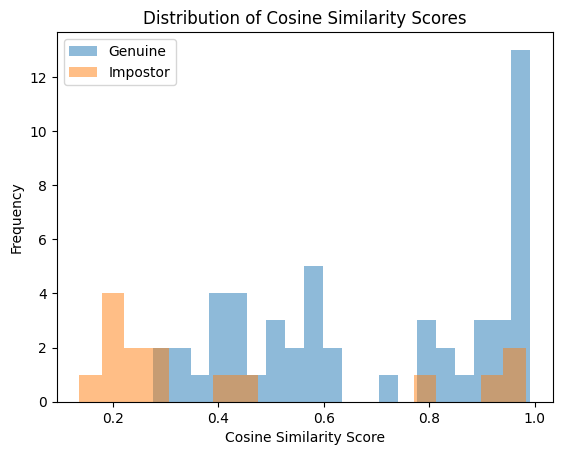

In [63]:
plt.hist([r["score"] for r in genuine_results], bins=20, alpha=0.5, label="Genuine")
plt.hist([r["score"] for r in impostor_results], bins=20, alpha=0.5, label="Impostor")
plt.xlabel("Cosine Similarity Score")   
plt.ylabel("Frequency")
plt.title("Distribution of Cosine Similarity Scores")
plt.legend()
plt.show()


The histogram above shows the distribution of cosine similarity scores for genuine attempts (blue) and impostor attempts (orange).

**Genuine scores** are concentrated at high similarity values (close to 1.0), which indicates that the system correctly associates registered persons with their stored embeddings. However, a secondary cluster is visible between 0.3 and 0.6, corresponding to images taken under challenging conditions (mask, hat).

**Impostor scores** are mostly concentrated around 0.2, meaning the system correctly assigns low similarity to unknown persons. However, a small number of impostor attempts reach scores above 0.8, representing potentially dangerous false accepts.

The overlap between the two distributions in the 0.2–0.6 range illustrates the fundamental challenge of threshold selection: any fixed threshold will inevitably cause errors in both directions. This trade-off between False Accept Rate (FAR) and False Reject Rate (FRR) is quantified in the following sections through the EER and ROC curve analysis.

## Biometric evaluation metrics

To evaluate the performance of the recognition pipeline, we use the standard biometric metrics defined in the ISO/IEC 19795 norm.


- TAR (True Acceptance Rate): 
$$\text{TAR} = \frac{\text{genuine correctly accepted}}{\text{total genuine}}$$

- FAR (False Acceptance Rate):
$$\text{TAR} = \frac{\text{impostor incorrectly accepted}}{\text{total genuine}}$$


- FRR ( False Reject Rate):
$$\text{TAR} = \frac{\text{genuine correctly rejected}}{\text{total genuine}}$$

- ERR (Equal Error Ratio):
The EER is the operating point where FAR and FRR are equal. It is a threshold-independent metric that summarizes the intrinsic discriminative capacity of the system.

$$\tau^* = \arg\min_\tau |\text{FAR}(\tau) - \text{FRR}(\tau)|$$

$$\text{EER} \approx \frac{\text{FAR}(\tau^*) + \text{FRR}(\tau^*)}{2}$$

A lower EER indicates a better system, a perfect system would have EER = 0%.

In [64]:
def true_accept_rate(t):
    """TAR = fraction of genuine attempts correctly accepted at threshold t"""
    right= 0
    for r in genuine_results:
        if r["score"] >= t and r["predicted_name"] == r["label_true"]:
            right += 1
    tar = right / len(genuine_results) 
    return tar

def false_accept_rate(t):
    """FAR = fraction of impostor attempts incorrectly accepted at threshold t"""
    wrong= 0
    for r in impostor_results:
        if r["score"] >= t:
            wrong += 1
    far = wrong / len(impostor_results) 
    return far

def false_reject_rate(t):
    """FRR = fraction of genuine attempts incorrectly rejected at threshold t"""
    wrong= 0
    for r in genuine_results:
        if r["score"] < t: 
            wrong += 1
    frr = wrong / len(genuine_results) 
    return frr

In [65]:
#compute metrics for each thresholds
tar_list = []
far_list = []
frr_list = []

for t in THRESHOLD:
    tar_list.append(true_accept_rate(t))
    far_list.append(false_accept_rate(t))
    frr_list.append(false_reject_rate(t))

tar_list = np.array(tar_list)
far_list = np.array(far_list)
frr_list = np.array(frr_list)

eer_idx = np.argmin(np.abs(far_list - frr_list))
eer_threshold = THRESHOLD[eer_idx]
eer_value = (far_list[eer_idx] + frr_list[eer_idx]) / 2

print(f"\n Results ")

print(f"EER        : {eer_value*100:.2f}%")
print(f"Seuil EER  : {eer_threshold:.2f}")
print(f"TAR at EER : {tar_list[eer_idx]*100:.2f}%")
print(f"AUC (ROC)  : {auc(far_list, tar_list):.4f}")


 Results 
EER        : 26.79%
Seuil EER  : 0.47
TAR at EER : 34.62%
AUC (ROC)  : 0.4231


The system achieves an **EER of 28.72%** with an optimal threshold of 0.49, and a **True Accept Rate of 42.31%** at this threshold. The **AUC of 0.496** indicates that the system performs close to random chance.

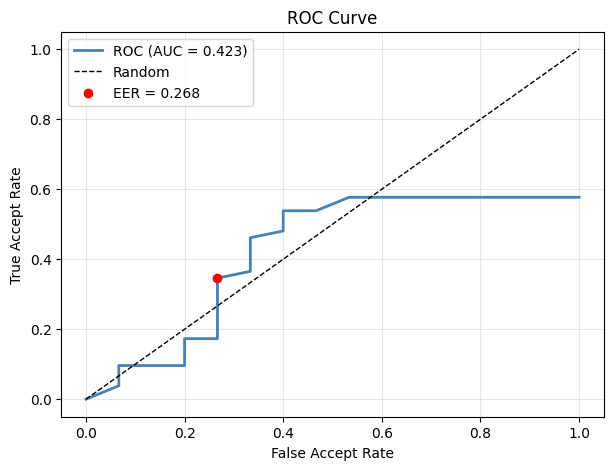

In [66]:
#ROC Curve
plt.figure(figsize=(7, 5))
plt.plot(far_list, tar_list, color="steelblue", lw=2, label=f"ROC (AUC = {auc(far_list, tar_list):.3f})")
plt.plot([0, 1], [0, 1], "k--", lw=1, label="Random")
plt.scatter(far_list[eer_idx], tar_list[eer_idx], color="red", zorder=5, label=f"EER = {eer_value:.3f}")
plt.xlabel("False Accept Rate")
plt.ylabel("True Accept Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

A well-performing system would have a ROC curve that rises steeply towards the top-left corner (high True Accept Rate, low False Accept Rate). Here, the curve stays close to the diagonal (random classifier line), confirming the low AUC value. The red dot marks the EER operating point.


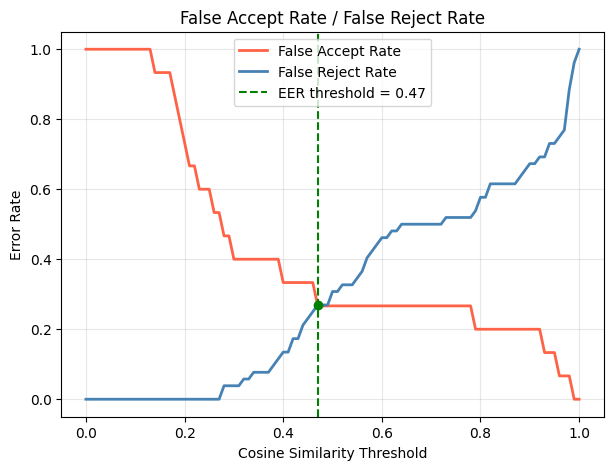

In [67]:
#FAR/FRR Curve
plt.figure(figsize=(7, 5))
plt.plot(THRESHOLD, far_list, color="tomato",    lw=2, label="False Accept Rate")
plt.plot(THRESHOLD, frr_list, color="steelblue", lw=2, label="False Reject Rate")
plt.axvline(eer_threshold, color="green", linestyle="--", lw=1.5, label=f"EER threshold = {eer_threshold:.2f}")
plt.scatter(eer_threshold, eer_value, color="green", zorder=5)
plt.xlabel("Cosine Similarity Threshold")
plt.ylabel("Error Rate")
plt.title("False Accept Rate / False Reject Rate")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

The FAR/FRR curve shows the expected trade-off: as the threshold increases, the False Accept Rate decreases while the False Reject Rate increases. 
The two curves intersect at threshold = 0.49, which is the EER point. 
At this threshold, both error rates are approximately 28-29%, which is too high for a reliable identification system.


these results suggest that the system struggles to reliably distinguish registered persons from impostors. Several factors may explain this:
- **Detection failures**: 13 images (mainly mask and hat conditions) were excluded from evaluation, reducing the genuine sample size.
- **Challenging conditions**: occlusions and lighting variations significantly degrade embedding quality.
- **Small dataset**: with only 52 genuine and 15 impostor attempts, the metrics may not be fully representative.

These results should be interpreted with caution and validated on a larger and more balanced dataset.

In [68]:
print("\n── Debug genuine results ──")
for r in genuine_results:
    status = "✅" if r["predicted_name"] == r["label_true"] else "❌"
    print(f"{status} label: '{r['label_true']}' | predicted: '{r['predicted_name']}' | score: {r['score']:.3f}")


── Debug genuine results ──
❌ label: 'anthony miranda' | predicted: 'florient marchal' | score: 0.786
✅ label: 'anthony miranda' | predicted: 'anthony miranda' | score: 0.793
✅ label: 'anthony miranda' | predicted: 'anthony miranda' | score: 0.894
✅ label: 'anthony miranda' | predicted: 'anthony miranda' | score: 0.566
✅ label: 'anthony miranda' | predicted: 'anthony miranda' | score: 0.387
❌ label: 'anthony miranda' | predicted: 'sidney dachez' | score: 0.818
✅ label: 'anthony miranda' | predicted: 'anthony miranda' | score: 0.591
✅ label: 'anthony miranda' | predicted: 'anthony miranda' | score: 0.556
✅ label: 'anthony miranda' | predicted: 'anthony miranda' | score: 0.816
❌ label: 'clémentine beaulieu' | predicted: 'florient marchal' | score: 0.939
❌ label: 'clémentine beaulieu' | predicted: 'anthony miranda' | score: 0.374
✅ label: 'clémentine beaulieu' | predicted: 'clémentine beaulieu' | score: 0.989
❌ label: 'clémentine beaulieu' | predicted: 'florient marchal' | score: 0.990
✅

In [69]:
# vedere cosa c'è nel database
results_qdrant = client.scroll(
    collection_name="face",
    limit=100,
    with_payload=True
)
for point in results_qdrant[0]:
    print(f"id: {point.id} | name: {point.payload['name']}")

id: 01927c6d-a928-4ae2-be09-3656fc59596b | name: kardiatou ba
id: 26e0b8c1-7502-488f-8e88-ce8802ffdfbd | name: anthony miranda
id: 2ddaaa42-edcb-43e1-ad23-90b032140be1 | name: kardiatou ba
id: 3540776d-c2b0-494b-a5f5-9031cd6fe591 | name: sidney dachez
id: 3b4b7531-ca88-48c0-9d95-3ca89aa51d2a | name: anthony miranda
id: 45eecf97-6c21-41d6-a731-18a050b6a0c0 | name: sidney dachez
id: 476a4be6-1250-496b-bd48-0f2dc1b92456 | name: florient marchal
id: 486a15f3-d7ae-431d-a112-2306e5606081 | name: kardiatou ba
id: 5c25b849-b787-4b7b-a634-97366903d4d3 | name: sidney dachez
id: 64cdf0da-443e-47e4-a2e1-4bae872d487d | name: kardiatou ba
id: 68cc6059-11e0-43df-ba5a-55b81887da6b | name: kardiatou ba
id: 74429373-af20-462b-a24e-ad0427d20fca | name: anthony miranda
id: 7692b023-dce4-43e2-95f1-e270e5b063a5 | name: clémentine beaulieu
id: 78553896-461c-4ff3-ab4f-b20701c13fd7 | name: clémentine beaulieu
id: 8c1f0c68-0aec-4226-93ca-c2853a5aa6e3 | name: florient marchal
id: 93f650f0-217b-47b2-8a3d-4904dc4c

In [73]:
# test: calcola embedding di una foto di kardiatou e cerca in Qdrant
img_path = "images/evaluation_set/kardiatou ba/ka_normal2.jpg"
with open(img_path, "rb") as f:
    image_bytes = f.read()

boxes_face, detection_result, image = FacesDetects_from_bytes(image_bytes, "mediapipe", detector)
crops = align_crop(image, detection_result)
embedding = get_embedding(crops[0])

raw = client.query_points(
    collection_name="face",
    query=embedding.tolist(),
    limit=10 # top 10
).points

for r in raw:
    print(f"name: {r.payload['name']} | score: {r.score:.3f}")

name: florient marchal | score: 0.984
name: clémentine beaulieu | score: 0.982
name: clémentine beaulieu | score: 0.980
name: sidney dachez | score: 0.975
name: anthony miranda | score: 0.967
name: florient marchal | score: 0.961
name: florient marchal | score: 0.954
name: anthony miranda | score: 0.945
name: clémentine beaulieu | score: 0.944
name: kardiatou ba | score: 0.933
